In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
sounds = ['GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_WINDS', 'GALAXY_SOUNDS_SOLAR_FLAMES']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in sounds or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
del row
del mid
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,GALAXY_SOUNDS_DARK_MATTER,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
1,2,0,GALAXY_SOUNDS_BLACK_HOLES,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
2,2,0,GALAXY_SOUNDS_SOLAR_FLAMES,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
3,2,0,GALAXY_SOUNDS_SOLAR_WINDS,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0
4,2,0,GALAXY_SOUNDS_PLANETARY_RINGS,9994,22,9992,26,,,10006,22,10008,26,,,10000.0,0.0


In [2]:
DARK_MATTER, BLACK_HOLES, RINGS, WINDS, FLAMES = sounds

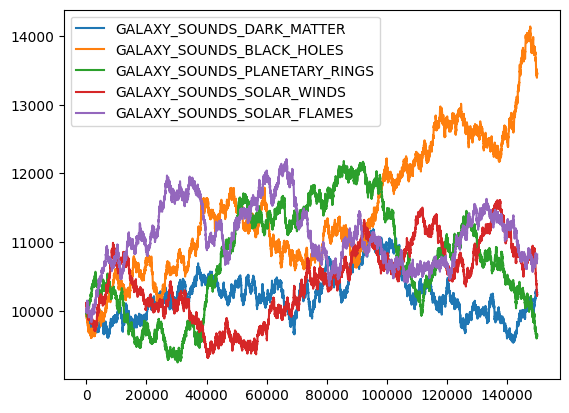

In [3]:
for p in sounds:
    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [4]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

<Axes: title={'center': 'Average mid'}, xlabel='timestamp'>

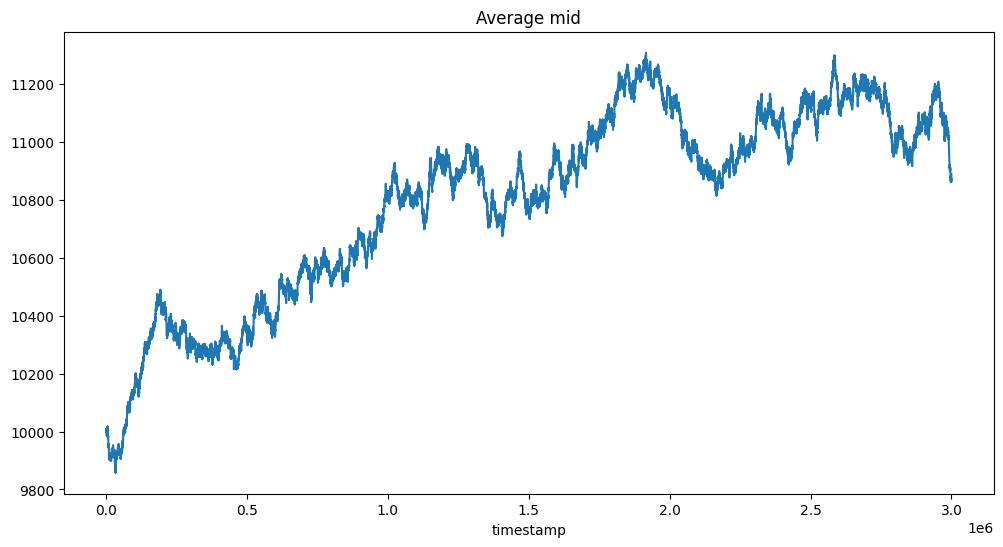

In [5]:
pebble_cols = [c for c in mids.columns if c.startswith("GALAXY")]
mids["GALAXY_avg"] = mids[pebble_cols].mean(axis=1)

mids["GALAXY_avg"].plot(figsize=(12, 6), title="Average mid")

# GALAXY_SOUNDS Deep Analysis

## Key Questions
1. Are the 5 products related (cointegrated, sum-constrained, etc)?
2. Do they trade together as a basket?
3. Is there a momentum or mean-reversion signal?
4. How does GALAXY compare to PEBBLES (which has a known sum constraint)?

In [7]:
# Load trade data and build pivot tables with short names
trade_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/trades_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

trades = pd.DataFrame(trade_rows)
trades['price'] = pd.to_numeric(trades['price'], errors='coerce')
trades['quantity'] = pd.to_numeric(trades['quantity'], errors='coerce')

SHORT = {
    'GALAXY_SOUNDS_BLACK_HOLES':    'BH',
    'GALAXY_SOUNDS_DARK_MATTER':    'DM',
    'GALAXY_SOUNDS_PLANETARY_RINGS':'PR',
    'GALAXY_SOUNDS_SOLAR_FLAMES':   'SF',
    'GALAXY_SOUNDS_SOLAR_WINDS':    'SW',
}
gal_prods = sorted([p for p in prices['product'].unique() if p.startswith('GALAXY')])
mids_full = prices[prices['product'].isin(gal_prods)].pivot_table(
    index='timestamp', columns='product', values='mid_price'
).sort_index().ffill().dropna()
mids_full.columns = [SHORT[c] for c in mids_full.columns]

print("Shape:", mids_full.shape)
print("\nStarting prices (Day 2 t=0):")
print(mids_full.iloc[0])
print(f"\nAll start at 10000: {(mids_full.iloc[0] == 10000).all()}")

Shape: (30000, 5)

Starting prices (Day 2 t=0):
BH    10000.0
DM    10000.0
PR    10000.0
SF    10000.0
SW    10000.0
Name: 0, dtype: float64

All start at 10000: True


## 1. Return Correlations — Are These Products Related?

In [8]:
rets = mids_full.diff().dropna()

print("=== Return correlations (all 3 days) ===")
print(rets.corr().round(4))

print("\n=== Individual return stats ===")
print(rets.agg(['mean','std']).T.round(4))

print("\n=== ADF unit-root test (all non-stationary?) ===")
for col in mids_full.columns:
    r = adfuller(mids_full[col], autolag='AIC')
    print(f"  {col}: ADF={r[0]:.3f}, p={r[1]:.4f}")

=== Return correlations (all 3 days) ===
        BH      DM      PR      SF      SW
BH  1.0000  0.0001  0.0016  0.0021  0.0103
DM  0.0001  1.0000  0.0065  0.0043 -0.0011
PR  0.0016  0.0065  1.0000  0.0137 -0.0000
SF  0.0021  0.0043  0.0137  1.0000  0.0042
SW  0.0103 -0.0011 -0.0000  0.0042  1.0000

=== Individual return stats ===
      mean      std
BH  0.1153  11.4793
DM  0.0088  10.2455
PR -0.0117  10.8789
SF  0.0274  11.0943
SW  0.0083  10.5391

=== ADF unit-root test (all non-stationary?) ===


  BH: ADF=-0.531, p=0.8858


  DM: ADF=-2.721, p=0.0705


  PR: ADF=-1.033, p=0.7409


  SF: ADF=-2.762, p=0.0639


  SW: ADF=-1.765, p=0.3978


## 2. Sum Constraint Test — GALAXY vs PEBBLES

PEBBLES has an EXACT sum = 50000 constraint (ADF p ≈ 0, std ≈ 2.8).
Does GALAXY have the same?

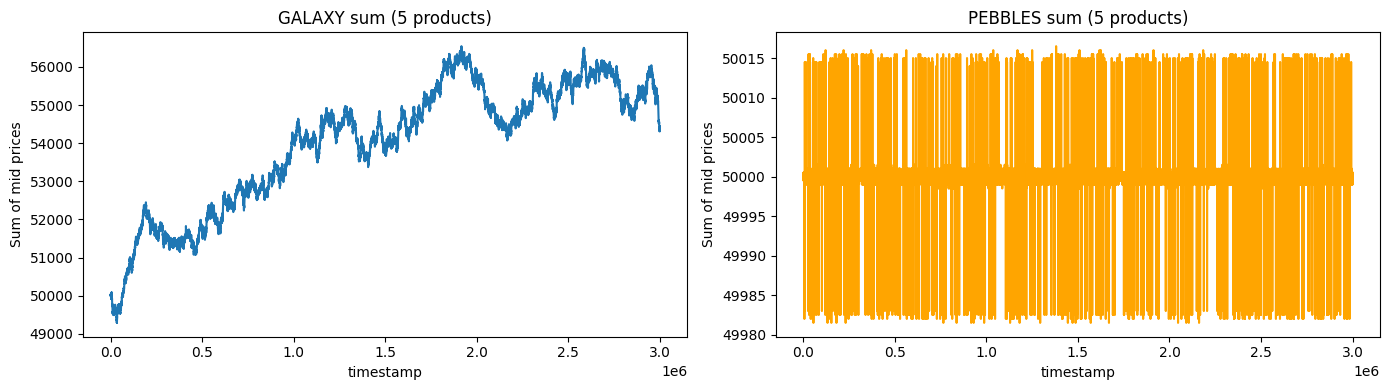

=== Sum statistics ===



GALAXY:
  sum mean = 53990.3, std = 1645.0, ADF p = 0.136106
  Sum-return std actual=24.48, expected-if-independent=24.26
  Ratio actual/expected = 1.009



PEBBLES:
  sum mean = 49999.9, std = 2.8, ADF p = 0.000000
  Sum-return std actual=3.93, expected-if-independent=40.49
  Ratio actual/expected = 0.097


In [9]:
from statsmodels.tsa.stattools import adfuller as adf

# Reload all prices (original notebook filtered to GALAXY-only)
all_price_rows = []
offset2 = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset2
            all_price_rows.append(row)
    offset2 += 1_000_000

prices_all = pd.DataFrame(all_price_rows)
for col in ['timestamp', 'mid_price']:
    prices_all[col] = pd.to_numeric(prices_all[col], errors='coerce')

# PEBBLES for comparison
peb_prods = sorted([p for p in prices_all['product'].unique() if p.startswith('PEBBLES')])
peb = prices_all[prices_all['product'].isin(peb_prods)].pivot_table(
    index='timestamp', columns='product', values='mid_price'
).sort_index().ffill().dropna()
peb.columns = [c.replace('PEBBLES_', '') for c in peb.columns]

gal_sum = mids_full.sum(axis=1)
peb_sum = peb.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
gal_sum.plot(ax=axes[0], title='GALAXY sum (5 products)')
axes[0].set_ylabel('Sum of mid prices')
peb_sum.plot(ax=axes[1], title='PEBBLES sum (5 products)', color='orange')
axes[1].set_ylabel('Sum of mid prices')
plt.tight_layout()
plt.show()

print("=== Sum statistics ===")
for label, s, base_df in [('GALAXY', gal_sum, mids_full), ('PEBBLES', peb_sum, peb)]:
    p = adf(s, autolag='AIC')[1]
    rets_s = s.diff().dropna()
    indiv_std = base_df.diff().dropna().std().mean()
    expected_std = indiv_std * np.sqrt(5)
    print(f"\n{label}:")
    print(f"  sum mean = {s.mean():.1f}, std = {s.std():.1f}, ADF p = {p:.6f}")
    print(f"  Sum-return std actual={rets_s.std():.2f}, expected-if-independent={expected_std:.2f}")
    print(f"  Ratio actual/expected = {rets_s.std()/expected_std:.3f}")

## 3. Basket Trade Structure

All 5 GALAXY products always trade at the SAME timestamp with the SAME quantity.
Is this a basket — and do they all move in the same direction?

In [10]:
gal_trades = trades[trades['symbol'].str.startswith('GALAXY', na=False)].copy()
gal_trades['sym'] = gal_trades['symbol'].map(SHORT)
trade_piv = gal_trades.pivot_table(index='timestamp', columns='sym', values='price')

ts_counts = gal_trades.groupby('timestamp')['symbol'].count()
print("=== Trades per timestamp (basket structure) ===")
print(ts_counts.value_counts().sort_index())
print(f"\nTotal basket events: {len(trade_piv)}")

# Verify: all events are ALL-BUY or ALL-SELL vs prev mid
def get_prev_mid(ts):
    locs = mids_full.index[mids_full.index < ts]
    return mids_full.loc[locs[-1]] if len(locs) > 0 else None

sign_counts = {}
events = []
for ts in trade_piv.index:
    prev = get_prev_mid(ts)
    if prev is None: continue
    t_row = trade_piv.loc[ts]
    signs = tuple(1 if t_row[c] > prev[c] else -1 for c in ['BH','DM','PR','SF','SW'])
    direction = 1 if signs[0] > 0 else -1
    key = '+++++' if direction == 1 else '-----'
    sign_counts[key] = sign_counts.get(key, 0) + 1
    events.append({'ts': ts, 'dir': direction, 'prev': prev.copy()})

print("\n=== Basket event direction (all 5 same direction?) ===")
for k, v in sorted(sign_counts.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v} events ({v/len(events)*100:.1f}%)")

# Show sample basket events
print("\n=== Sample basket events (trade price - prev mid) ===")
for ev in events[:5]:
    ts = ev['ts']
    diffs = {c: round(trade_piv.loc[ts, c] - ev['prev'][c], 1) for c in ['BH','DM','PR','SF','SW']}
    print(f"  t={ts}: dir={'BUY' if ev['dir']==1 else 'SELL'}, diffs={diffs}")

=== Trades per timestamp (basket structure) ===
symbol
5    733
Name: count, dtype: int64

Total basket events: 733



=== Basket event direction (all 5 same direction?) ===
  -----: 375 events (51.2%)
  +++++: 358 events (48.8%)

=== Sample basket events (trade price - prev mid) ===
  t=1700: dir=BUY, diffs={'BH': np.float64(6.5), 'DM': np.float64(-7.5), 'PR': np.float64(-1.5), 'SF': np.float64(-17.5), 'SW': np.float64(-21.5)}
  t=14500: dir=BUY, diffs={'BH': np.float64(1.5), 'DM': np.float64(9.5), 'PR': np.float64(5.5), 'SF': np.float64(-0.5), 'SW': np.float64(-14.5)}
  t=15100: dir=BUY, diffs={'BH': np.float64(6.5), 'DM': np.float64(17.5), 'PR': np.float64(8.5), 'SF': np.float64(14.5), 'SW': np.float64(15.0)}
  t=26500: dir=BUY, diffs={'BH': np.float64(13.5), 'DM': np.float64(-4.5), 'PR': np.float64(14.5), 'SF': np.float64(12.5), 'SW': np.float64(-11.5)}
  t=36400: dir=SELL, diffs={'BH': np.float64(-10.5), 'DM': np.float64(-10.5), 'PR': np.float64(22.5), 'SF': np.float64(-5.5), 'SW': np.float64(0.5)}


## 4. Momentum Signal from Basket Events

After a basket BUY event (all 5 hit the ask), do prices continue rising?
After a basket SELL, do prices continue falling?

=== Average price change per product after basket event ===
   Lookahead    BUY avg   SELL avg     Diff
         100      +1.07      -1.44    +2.50
         500      +1.93      -1.52    +3.45
        1000      +1.13      -1.44    +2.57
        5000      +1.28      -0.86    +2.14
       10000      +0.53      -2.01    +2.54


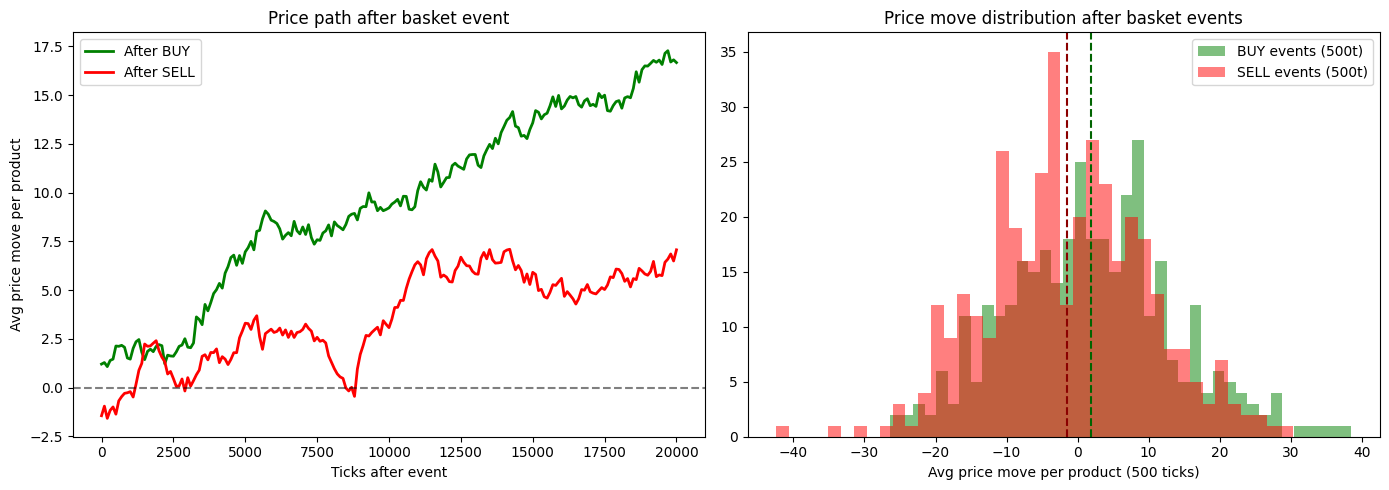

In [11]:
def get_mid_offset(ts, offset_ticks):
    target = ts + offset_ticks
    locs = mids_full.index[mids_full.index <= target]
    return mids_full.loc[locs[-1]] if len(locs) > 0 else None

lookaheads = [100, 500, 1000, 5000, 10000]
results = {la: {'buy': [], 'sell': []} for la in lookaheads}

for ev in events:
    for la in lookaheads:
        fut = get_mid_offset(ev['ts'], la)
        if fut is None: continue
        avg_move = (fut - ev['prev']).mean()  # avg price change per product
        key = 'buy' if ev['dir'] == 1 else 'sell'
        results[la][key].append(avg_move)

print("=== Average price change per product after basket event ===")
print(f"{'Lookahead':>12} {'BUY avg':>10} {'SELL avg':>10} {'Diff':>8}")
for la in lookaheads:
    b = np.mean(results[la]['buy'])
    s = np.mean(results[la]['sell'])
    print(f"{la:>12} {b:>+10.2f} {s:>+10.2f} {b-s:>+8.2f}")

# Visualize: cumulative price path after buy vs sell events
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_la = 20000
step = 100

for ev_type, color, label in [(1, 'green', 'After BUY'), (-1, 'red', 'After SELL')]:
    typed_events = [e for e in events if e['dir'] == ev_type][:150]
    paths = []
    for ev in typed_events:
        path = []
        for t_offset in range(0, max_la + step, step):
            fut = get_mid_offset(ev['ts'], t_offset)
            if fut is None:
                break
            path.append((fut - ev['prev']).mean())
        if len(path) == (max_la // step + 1):
            paths.append(path)
    if paths:
        avg_path = np.mean(paths, axis=0)
        t_axis = np.arange(0, max_la + step, step)
        axes[0].plot(t_axis[:len(avg_path)], avg_path, color=color, label=label, linewidth=2)

axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Ticks after event')
axes[0].set_ylabel('Avg price move per product')
axes[0].set_title('Price path after basket event')
axes[0].legend()

# Distribution of move sizes
buy_500 = results[500]['buy']
sell_500 = results[500]['sell']
axes[1].hist(buy_500, bins=40, alpha=0.5, color='green', label='BUY events (500t)')
axes[1].hist(sell_500, bins=40, alpha=0.5, color='red', label='SELL events (500t)')
axes[1].axvline(np.mean(buy_500), color='darkgreen', linestyle='--')
axes[1].axvline(np.mean(sell_500), color='darkred', linestyle='--')
axes[1].set_xlabel('Avg price move per product (500 ticks)')
axes[1].set_title('Price move distribution after basket events')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Trend Analysis — BH is the Outlier

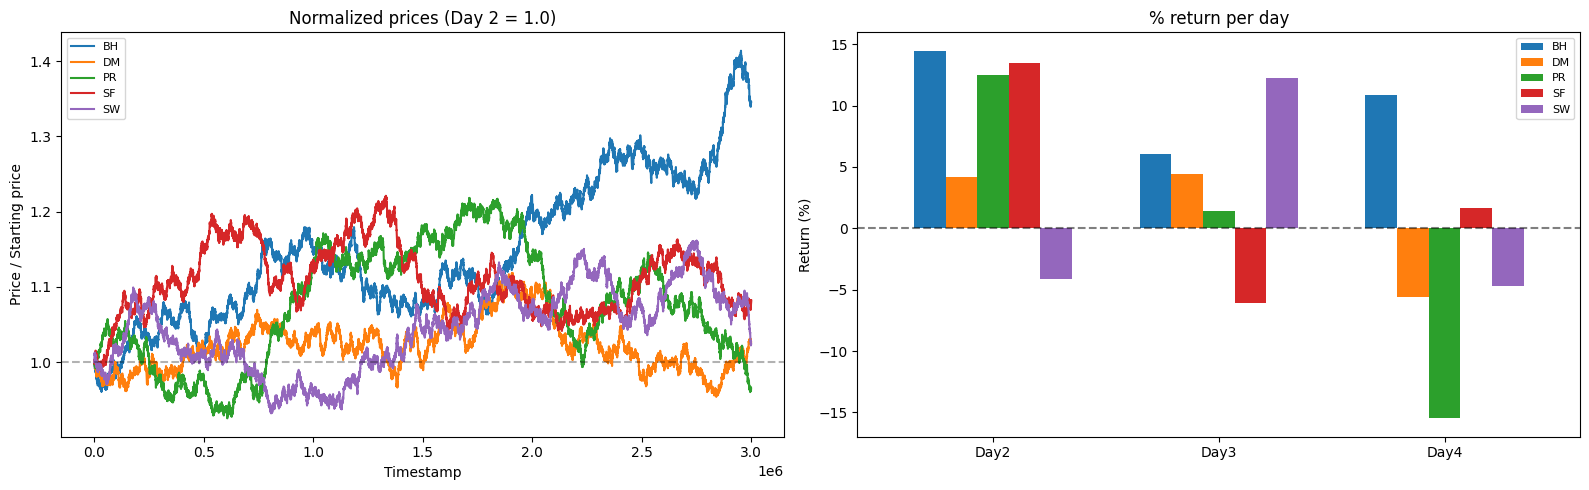

=== Total % change over 3 days ===
BH    34.58
DM     2.65
PR    -3.52
SF     8.23
SW     2.48

BH trend is 14.1x the average of others


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Normalized prices
norm = mids_full / mids_full.iloc[0]
for col in norm.columns:
    axes[0].plot(norm.index, norm[col], label=col, linewidth=1.5)
axes[0].set_title('Normalized prices (Day 2 = 1.0)')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Price / Starting price')
axes[0].legend(fontsize=8)
axes[0].axhline(1.0, color='black', linestyle='--', alpha=0.3)

# Total return per day
day_bounds = [(0, 1_000_000, 'Day2'), (1_000_000, 2_000_000, 'Day3'), (2_000_000, 3_000_000, 'Day4')]
day_rets = {}
for start, end, label in day_bounds:
    mask = (mids_full.index >= start) & (mids_full.index < end)
    d = mids_full[mask]
    if len(d) > 0:
        day_rets[label] = (d.iloc[-1] / d.iloc[0] - 1) * 100

df_rets = pd.DataFrame(day_rets).T
df_rets.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('% return per day')
axes[1].set_ylabel('Return (%)')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("=== Total % change over 3 days ===")
total_ret = (mids_full.iloc[-1] / mids_full.iloc[0] - 1) * 100
print(total_ret.round(2).to_string())
print(f"\nBH trend is {total_ret['BH'] / total_ret[['DM','PR','SF','SW']].mean():.1f}x the average of others")

## 6. Summary of Findings

### What IS the relationship?

| Feature | PEBBLES | GALAXY |
|---|---|---|
| Sum constraint | **YES: sum = 50000 exactly** (ADF p≈0, std=2.8) | **NO** (ADF p=0.14, std=1645, ratio≈1.0) |
| Return correlations | XL has -0.5 with all others | All pairs ≈ 0.00 |
| Independent? | NO (XL is a derivative of the others) | YES (truly independent) |

### Key findings for GALAXY:

1. **Independent random walks**: All 5 products move completely independently.  
   - Return correlations < 0.015 for all pairs  
   - Sum return std ≈ √5 × individual std (what you'd expect if independent)  
   - No cointegration, no sum constraint

2. **Basket trading structure**: A hidden agent ALWAYS trades all 5 simultaneously  
   - 733 basket events over 3 days (~244/day)  
   - Every event is either ALL-BUY or ALL-SELL (+/−6 from mid)  
   - ~50/50 buy vs sell split

3. **Momentum signal**: Basket events predict subsequent price direction  
   - After BUY basket: avg price continues +1 to +2 per product  
   - After SELL basket: avg price continues −1 to −1.5 per product  
   - Effect persists for 500–10,000 ticks

4. **BH is the outlier**: BLACK_HOLES trends strongly upward (+34.6% over 3 days)  
   - Others are more range-bound (DM +2.7%, PR −3.5%, SF +8.2%, SW +2.5%)

### Trading implications:
- **Market-make all 5 independently** — no basket arbitrage exists (unlike PEBBLES)
- **Follow basket momentum**: after a basket BUY, stay long all 5; after SELL, short
- **Long bias on BH**: consistent upward drift across all 3 days

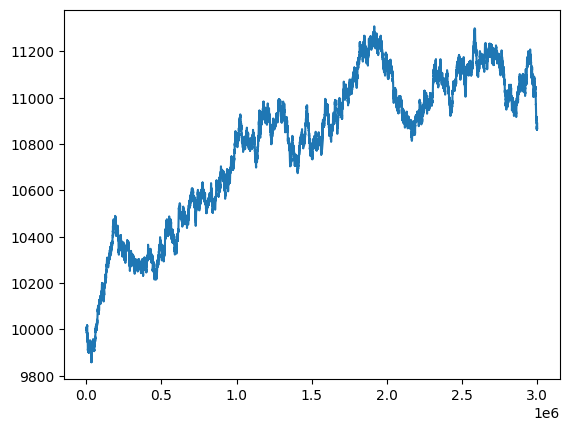